<a href="https://colab.research.google.com/github/Nanthakan670510759/229352-Labs/blob/main/Lab05_decision_tree_bagging_RF_670510759_Nanthakan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #5

#### Load data at: https://donlapark.pages.dev/229352/heart_disease.csv

* Decision tree ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html))
* Random hyperparameter search using cross-validation ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html))

In [2]:
import pandas as pd
import graphviz

from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# import data
data = pd.read_csv("heart_disease.csv", na_values="?")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,label
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:

# split into X and y
y = data["label"]
X = data.drop("label", axis=1)

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# impute missing values
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Create a decision tree
clf = DecisionTreeClassifier()

![5CV](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

In [4]:
params = {'max_depth': [3, 6, 9, 12]}

gridcv = GridSearchCV(clf, params, scoring='accuracy', cv=5)
gridcv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 6, 9, 12]}, scoring='accuracy')

In [5]:
gridcv.best_estimator_

DecisionTreeClassifier(max_depth=3)

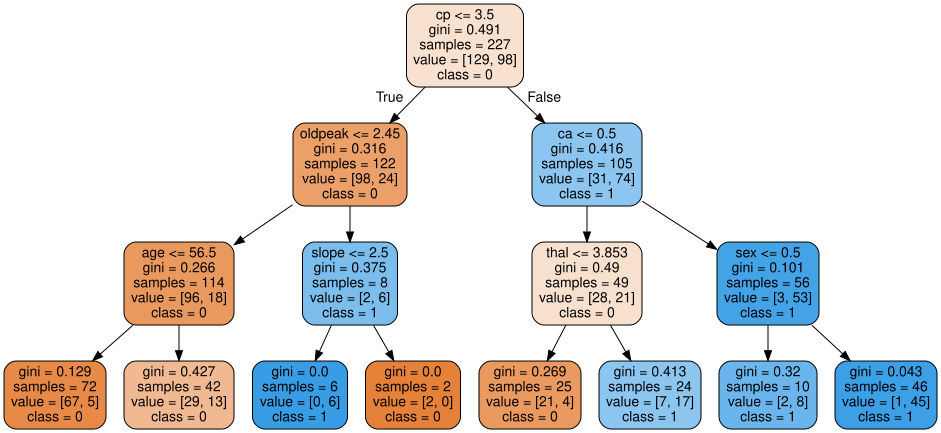

In [6]:
plot_data = export_graphviz(gridcv.best_estimator_,
                            out_file=None,
                            filled=True,
                            rounded=True,
                            feature_names=data.columns[:-1],
                            class_names=['0', '1'])

graph = graphviz.Source(plot_data)
graph

In [7]:
from sklearn.metrics import classification_report

ypred=gridcv.predict(X_test)
print(classification_report(y_test, ypred))

              precision    recall  f1-score   support

           0       0.73      0.91      0.81        35
           1       0.91      0.71      0.79        41

    accuracy                           0.80        76
   macro avg       0.82      0.81      0.80        76
weighted avg       0.82      0.80      0.80        76



## Bagged decision trees
* Bagging classifier ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html))

In [8]:
clf = DecisionTreeClassifier()
bagged_trees=BaggingClassifier(clf,n_estimators=100,max_samples=X_train.shape[0],max_features=5)
bagged_trees.fit(X_train,y_train)

ypred_bt=bagged_trees.predict(X_test)
print(classification_report(y_test, ypred_bt))

              precision    recall  f1-score   support

           0       0.71      0.86      0.78        35
           1       0.85      0.71      0.77        41

    accuracy                           0.78        76
   macro avg       0.78      0.78      0.78        76
weighted avg       0.79      0.78      0.78        76



## Random forest classifier
* Random forest ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html))

In [9]:
rf=RandomForestClassifier(n_estimators=200)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200)

#### Exercise
1. Study the hyperparameters of three models: [Decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [Bagged Decision Trees](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) and [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
2. For each model, use pipeline+grid search cross-validation across multiple hyperparameters to find the best model.
* Decision tree: choose at least 3 hyperparameters
* Bagged decision trees: choose at least 3 hyperparameters
* Random forest: choose at least 3 hyperparameters
3. For each model, compute the `f1_macro` and `accuracy` score on the test set.
* What is your best model?
* Plot the best tree model
* What hyperparameters did you choose? (explain in words, not in `sklearn's` parameter name)
* What are the best values of your hyperparameters?

# Decision tree

In [37]:
pipeline = Pipeline([('df', DecisionTreeClassifier(random_state=42))])

params={
    'df__criterion': ['gini', 'entropy'],
    'df__max_depth': [5,10,15],
    'df__min_samples_split': [2, 5, 10],
    'df__min_samples_leaf': [1, 2, 4]
}

gridcv=GridSearchCV(
    pipeline,
    params,
    scoring='accuracy',
    cv=5
)

gridcv.fit(X_train, y_train)
gridcv.best_estimator_


Pipeline(steps=[('df',
                 DecisionTreeClassifier(criterion='entropy', max_depth=5,
                                        random_state=42))])

In [38]:
ypred=gridcv.predict(X_test)
print(classification_report(y_test, ypred))

              precision    recall  f1-score   support

           0       0.70      0.89      0.78        35
           1       0.88      0.68      0.77        41

    accuracy                           0.78        76
   macro avg       0.79      0.78      0.78        76
weighted avg       0.80      0.78      0.78        76



# Bagged decision trees

In [42]:
pipeline = Pipeline([
    ('bag', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

params = {
    'bag__n_estimators': [50, 100, 200],
    'bag__max_features': [3, 5, None],
    'bag__max_samples': [0.5, 0.8, 1.0]
}

gridcv = GridSearchCV(
    pipeline,
    params,
    scoring='accuracy',
    cv=5
)

gridcv.fit(X_train, y_train)
gridcv.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

Pipeline(steps=[('bag',
                 BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                   max_features=5, max_samples=0.5,
                                   n_estimators=200, random_state=42))])

In [33]:
ypred_bt=gridcv.predict(X_test)
print(classification_report(y_test, ypred_bt))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85        35
           1       0.92      0.80      0.86        41

    accuracy                           0.86        76
   macro avg       0.86      0.86      0.86        76
weighted avg       0.86      0.86      0.86        76



# Random forest

In [34]:
pipeline = Pipeline([('rf', RandomForestClassifier(random_state=42))])

params = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

gridcv = GridSearchCV(
    pipeline,
    params,
    scoring='accuracy',
    cv=5
)

gridcv.fit(X_train, y_train)
gridcv.best_estimator_


Pipeline(steps=[('rf',
                 RandomForestClassifier(min_samples_split=10, n_estimators=300,
                                        random_state=42))])

In [35]:
ypred_rf=gridcv.predict(X_test)
print(classification_report(y_test, ypred_rf))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84        35
           1       0.91      0.78      0.84        41

    accuracy                           0.84        76
   macro avg       0.85      0.85      0.84        76
weighted avg       0.85      0.84      0.84        76



What is your best model?

**answer** Bagged decision trees 0.86

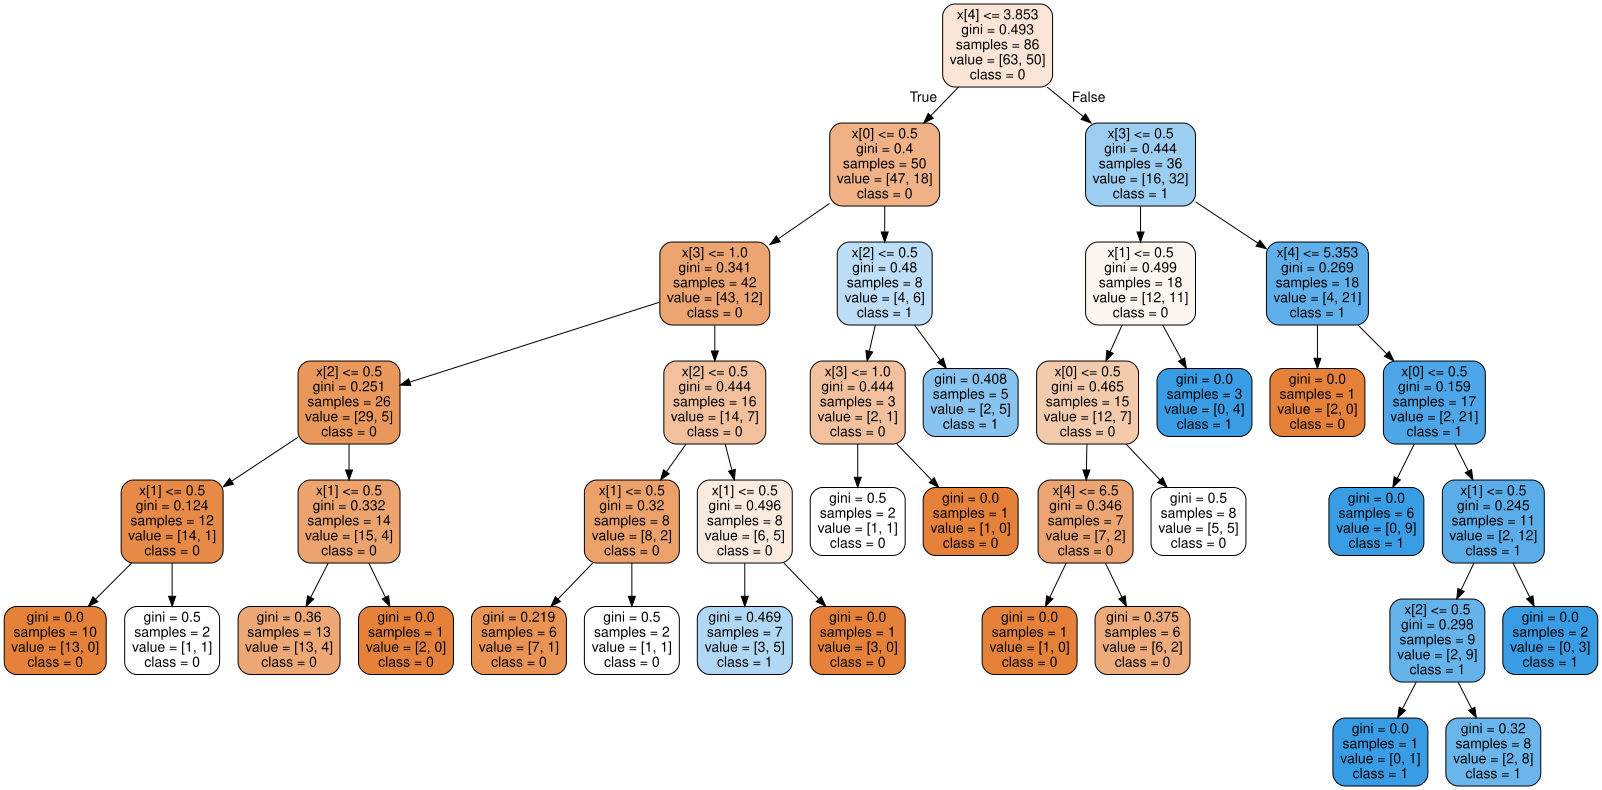

In [47]:
from sklearn.tree import export_graphviz
import graphviz

bestbag=gridcv.best_estimator_.named_steps['bag']
tree=bestbag.estimators_[0]

plot_data=export_graphviz(
    tree,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=None,
    class_names=['0', '1']
)

graph = graphviz.Source(plot_data)
graph


What hyperparameters did you choose? (explain in words, not in sklearn's parameter name)

**answer**

-จำนวนของ decision trees ที่ถูกสร้างขึ้นใน bagging model
การเพิ่มจำนวนต้นไม้ช่วยลดความแปรปรวนของโมเดลและทำให้ผลการทำนายมีความเสถียรมากขึ้น

-จำนวนตัวแปรที่ถูกสุ่มมาใช้ในการฝึก decision tree แต่ละต้น
การสุ่มใช้เพียงบางส่วนของ feature ช่วยลดความสัมพันธ์ระหว่างต้นไม้และเพิ่มประสิทธิภาพของ bagging

-จำนวนข้อมูลที่ถูกสุ่มมาใช้ฝึก decision tree แต่ละต้น
การควบคุมจำนวนข้อมูลช่วยสร้างความหลากหลายให้กับต้นไม้ใน ensemble

What are the best values of your hyperparameters?

**answer**

จำนวน decision tree = 200

จำนวน features = 5

จำนวนข้อมูลที่ใช้ฝึกในต้นไม้แต่ละต้น = 0.5